In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats
df =pd.read_csv(r"C:\Users\user\Downloads\boston.csv")
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [2]:
print(df.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')


In [4]:
print(df.shape)
print(df.info())

(506, 14)
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [5]:
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

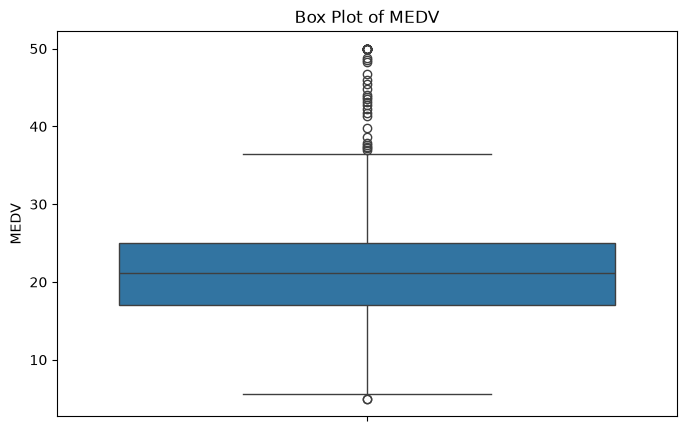

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['MEDV'])

plt.title("Box Plot of MEDV")
plt.ylabel("MEDV")

plt.show()

In [7]:
Q1 = df['MEDV'].quantile(0.25)
Q3 = df['MEDV'].quantile(0.75)

print("Q1 =", Q1)
print("Q3 =", Q3)

Q1 = 17.025
Q3 = 25.0


In [8]:
IQR = Q3 - Q1
print("IQR =", IQR)

IQR = 7.975000000000001


In [9]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower Limit =", lower_limit)
print("Upper Limit =", upper_limit)

Lower Limit = 5.0624999999999964
Upper Limit = 36.962500000000006


In [10]:
outliers_iqr = df[
    (df['MEDV'] < lower_limit) |
    (df['MEDV'] > upper_limit)
]

print("Outliers detected using IQR:")
print(outliers_iqr)

Outliers detected using IQR:
         CRIM    ZN  INDUS  CHAS     NOX     RM    AGE     DIS  RAD    TAX  \
97    0.12083   0.0   2.89     0  0.4450  8.069   76.0  3.4952    2  276.0   
98    0.08187   0.0   2.89     0  0.4450  7.820   36.9  3.4952    2  276.0   
157   1.22358   0.0  19.58     0  0.6050  6.943   97.4  1.8773    5  403.0   
161   1.46336   0.0  19.58     0  0.6050  7.489   90.8  1.9709    5  403.0   
162   1.83377   0.0  19.58     1  0.6050  7.802   98.2  2.0407    5  403.0   
163   1.51902   0.0  19.58     1  0.6050  8.375   93.9  2.1620    5  403.0   
166   2.01019   0.0  19.58     0  0.6050  7.929   96.2  2.0459    5  403.0   
179   0.05780   0.0   2.46     0  0.4880  6.980   58.4  2.8290    3  193.0   
180   0.06588   0.0   2.46     0  0.4880  7.765   83.3  2.7410    3  193.0   
182   0.09103   0.0   2.46     0  0.4880  7.155   92.2  2.7006    3  193.0   
186   0.05602   0.0   2.46     0  0.4880  7.831   53.6  3.1992    3  193.0   
190   0.09068  45.0   3.44     0  0